# Train TabR terpisah per phase (before vs after)

- basis split mengikuti pola v9/v8: external event-based, bukan subject-held-out
- latih 2 model terpisah: `before` dan `after`
- bandingkan performa internal dan external per phase


In [1]:
import os
import re
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == 'preprocess-anxiety':
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f'Project root: {ROOT}')


Project root: /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st


In [2]:
import random

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from joblib import dump
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger, TensorBoardLogger

from core.data_module import TabRDataModule
from core.TabR import LitTabR


In [3]:
FEATURES_PATH = ROOT / 'output/apex/features/poc_abs_flatten_ordered.xlsx'
TRAIN_ROOT = ROOT / 'output/apex/train'
N_EXTERNAL_PER_LABEL = 20
BATCH_SIZE = 128
MAX_EPOCHS = 50
RANDOM_SEED = 42
THRESHOLD = 0.5
LR = 3e-4
FREEZE_CONTEXT_EPOCH = MAX_EPOCHS // 4
M_NEIGHBORS = 8
EARLY_STOPPING_PATIENCE = 6
PHASES = ['before', 'after']

TRAIN_ROOT.mkdir(parents=True, exist_ok=True)
print(FEATURES_PATH)
print(TRAIN_ROOT)
print({'lr': LR, 'freeze_context_epoch': FREEZE_CONTEXT_EPOCH, 'm': M_NEIGHBORS, 'patience': EARLY_STOPPING_PATIENCE, 'phases': PHASES})


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/features/poc_abs_flatten_ordered.xlsx
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train
{'lr': 0.0003, 'freeze_context_epoch': 12, 'm': 8, 'patience': 6, 'phases': ['before', 'after']}


In [4]:
def get_next_train_dir(train_root: Path) -> Path:
    existing = []
    for path in train_root.iterdir():
        if path.is_dir() and re.fullmatch(r't\d+', path.name):
            existing.append(int(path.name[1:]))
    next_idx = max(existing, default=0) + 1
    out_dir = train_root / f't{next_idx}'
    out_dir.mkdir(parents=True, exist_ok=False)
    return out_dir


def plot_lightning_metrics(metrics_csv):
    df = pd.read_csv(metrics_csv)

    if 'epoch' not in df.columns:
        raise ValueError('Kolom epoch tidak ada')

    df_epoch = (
        df.sort_values('step')
          .groupby('epoch', as_index=False)
          .last()
    )

    plt.figure()
    if 'train_loss' in df_epoch:
        plt.plot(df_epoch['epoch'], df_epoch['train_loss'], label='Train Loss')
    if 'val_loss' in df_epoch:
        plt.plot(df_epoch['epoch'], df_epoch['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    if 'train_acc' in df_epoch:
        plt.plot(df_epoch['epoch'], df_epoch['train_acc'], label='Train Accuracy')
    if 'val_acc' in df_epoch:
        plt.plot(df_epoch['epoch'], df_epoch['val_acc'], label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()


def visualize_results(model_dir):
    model_dir = str(model_dir).rstrip('/')

    cm_files = {
        'Internal': os.path.join(model_dir, 'cm_internal.png'),
        'External': os.path.join(model_dir, 'cm_external.png'),
    }

    report_files = {
        'Internal': os.path.join(model_dir, 'report_internal.csv'),
        'External': os.path.join(model_dir, 'report_external.csv'),
    }

    for name, path in cm_files.items():
        if not os.path.exists(path):
            print(f'Missing {path}')
            continue
        img = mpimg.imread(path)
        plt.figure(figsize=(5, 4))
        plt.imshow(img)
        plt.axis('off')
        plt.title(name)
        plt.show()

    for name, path in report_files.items():
        if not os.path.exists(path):
            print(f'Missing {path}')
            continue
        df_report = pd.read_csv(path, index_col=0)
        print(f'\n=== {name.upper()} CLASSIFICATION REPORT ===')
        print(df_report)


def evaluate_model(model, loader, threshold=0.5):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:
            logits = model(x)
            prob = torch.softmax(logits, dim=1)[:, 1]
            preds = (prob > threshold).long()
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, sup = precision_recall_fscore_support(y_true, y_pred, average=None)

    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'support': sup,
        'cm': confusion_matrix(y_true, y_pred),
        'report': classification_report(y_true, y_pred, output_dict=True),
    }


def save_confusion_matrix(cm, labels, out_path, title):
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()


def balance_context_by_label(X, y, max_per_class=None):
    idx0 = (y == 0).nonzero(as_tuple=True)[0]
    idx1 = (y == 1).nonzero(as_tuple=True)[0]
    n = min(len(idx0), len(idx1))
    if max_per_class is not None:
        n = min(n, max_per_class)
    idx0 = idx0[torch.randperm(len(idx0))[:n]]
    idx1 = idx1[torch.randperm(len(idx1))[:n]]
    idx = torch.cat([idx0, idx1])
    idx = idx[torch.randperm(len(idx))]
    return X[idx], y[idx]


def balanced_external_events(event_table: pd.DataFrame, n_per_label: int, seed: int = 42) -> set[str]:
    rng = random.Random(seed)
    selected_ids: list[str] = []

    for label_name in ['anxiety_rendah', 'anxiety_tinggi']:
        label_df = event_table[event_table['label'] == label_name].copy()
        if label_df.empty:
            continue

        picked_rows = []
        used_ids = set()

        participant_groups = []
        for participant, part_df in label_df.groupby('participant', sort=True):
            part_df = part_df.sort_values(['phase', 'question', 'clip', 'event_clip'], kind='stable')
            phase_groups = []
            for phase, phase_df in part_df.groupby('phase', sort=True):
                phase_groups.append(phase_df.to_dict('records'))
            participant_groups.append((participant, phase_groups))

        while len(picked_rows) < n_per_label:
            progress = False
            for _participant, phase_groups in participant_groups:
                for records in phase_groups:
                    while records and records[0]['event_id'] in used_ids:
                        records.pop(0)
                    if not records:
                        continue
                    row = records.pop(0)
                    picked_rows.append(row)
                    used_ids.add(row['event_id'])
                    progress = True
                    if len(picked_rows) >= n_per_label:
                        break
                if len(picked_rows) >= n_per_label:
                    break
            if not progress:
                break

        if len(picked_rows) < n_per_label:
            remaining = label_df[~label_df['event_id'].isin(used_ids)].sort_values(['participant', 'phase', 'question', 'clip', 'event_clip'], kind='stable')
            for row in remaining.to_dict('records'):
                picked_rows.append(row)
                used_ids.add(row['event_id'])
                if len(picked_rows) >= n_per_label:
                    break

        selected_ids.extend([row['event_id'] for row in picked_rows[:n_per_label]])

    return set(selected_ids)


In [5]:
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.set_float32_matmul_precision('medium')

df = pd.read_excel(FEATURES_PATH)
print(df.shape)
df[['phase', 'label', 'participant', 'clip', 'event_clip', 'frame']].head()


(57656, 405)


,phase,label,participant,clip,event_clip,frame
0,before,anxiety_tinggi,aaisyah_nursalsabiil_ni_patriarti,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,2
1,before,anxiety_tinggi,aaisyah_nursalsabiil_ni_patriarti,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,3
2,before,anxiety_tinggi,aaisyah_nursalsabiil_ni_patriarti,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,4
3,before,anxiety_tinggi,aaisyah_nursalsabiil_ni_patriarti,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,5
4,before,anxiety_tinggi,aaisyah_nursalsabiil_ni_patriarti,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,6


In [6]:
label_map = {
    'anxiety_rendah': 0,
    'anxiety_tinggi': 1,
}

df = df[df['label'].isin(label_map)].copy()
df['target'] = df['label'].map(label_map)
df['event_id'] = df['phase'].astype(str) + '||' + df['participant'].astype(str) + '||' + df['question'].astype(str) + '||' + df['clip'].astype(str) + '||' + df['event_clip'].astype(str)

meta_cols = [
    'phase', 'condition', 'label', 'participant', 'participant_raw', 'question', 'question_no',
    'sample', 'clip', 'event_clip', 'event_no', 'clip_path', 'frame', 'target', 'event_id',
]
feature_cols = [c for c in df.columns if c not in meta_cols]
print('n_features =', len(feature_cols))
feature_cols[:10]


n_features = 392


['mulut_x1',
 'mulut_y1',
 'mulut_t1',
 'mulut_m1',
 'mulut_x2',
 'mulut_y2',
 'mulut_t2',
 'mulut_m2',
 'mulut_x3',
 'mulut_y3']

In [7]:
def prepare_phase_split(df_phase: pd.DataFrame, phase_name: str):
    event_table_phase = df_phase[['event_id', 'label', 'target', 'phase', 'participant', 'question', 'clip', 'event_clip']].drop_duplicates().reset_index(drop=True)

    external_event_ids_phase = balanced_external_events(event_table_phase, N_EXTERNAL_PER_LABEL, seed=RANDOM_SEED)
    df_external_phase = df_phase[df_phase['event_id'].isin(external_event_ids_phase)].copy()
    df_train_all_phase = df_phase[~df_phase['event_id'].isin(external_event_ids_phase)].copy()

    train_events_phase = event_table_phase[~event_table_phase['event_id'].isin(external_event_ids_phase)].copy()
    train_event_ids_phase, val_event_ids_phase = train_test_split(
        train_events_phase['event_id'],
        test_size=0.2,
        stratify=train_events_phase['target'],
        random_state=RANDOM_SEED,
    )

    train_event_ids_phase = set(train_event_ids_phase.tolist())
    val_event_ids_phase = set(val_event_ids_phase.tolist())

    df_tr_phase = df_train_all_phase[df_train_all_phase['event_id'].isin(train_event_ids_phase)].copy()
    df_val_phase = df_train_all_phase[df_train_all_phase['event_id'].isin(val_event_ids_phase)].copy()

    imputer_phase = SimpleImputer(strategy='mean')
    scaler_phase = StandardScaler()

    X_train_np_phase = scaler_phase.fit_transform(imputer_phase.fit_transform(df_tr_phase[feature_cols]))
    X_val_np_phase = scaler_phase.transform(imputer_phase.transform(df_val_phase[feature_cols]))
    X_ext_np_phase = scaler_phase.transform(imputer_phase.transform(df_external_phase[feature_cols]))

    X_train_phase = torch.tensor(X_train_np_phase, dtype=torch.float32)
    y_train_phase = torch.tensor(df_tr_phase['target'].values, dtype=torch.long)
    X_val_phase = torch.tensor(X_val_np_phase, dtype=torch.float32)
    y_val_phase = torch.tensor(df_val_phase['target'].values, dtype=torch.long)
    X_ext_phase = torch.tensor(X_ext_np_phase, dtype=torch.float32)
    y_ext_phase = torch.tensor(df_external_phase['target'].values, dtype=torch.long)

    ctx_train_X_phase, ctx_train_y_phase = balance_context_by_label(X_train_phase, y_train_phase)
    ctx_val_X_phase, ctx_val_y_phase = X_val_phase, y_val_phase

    return {
        'phase': phase_name,
        'event_table': event_table_phase,
        'external_event_ids': external_event_ids_phase,
        'df_tr': df_tr_phase,
        'df_val': df_val_phase,
        'df_external': df_external_phase,
        'imputer': imputer_phase,
        'scaler': scaler_phase,
        'X_train': X_train_phase,
        'y_train': y_train_phase,
        'X_val': X_val_phase,
        'y_val': y_val_phase,
        'X_ext': X_ext_phase,
        'y_ext': y_ext_phase,
        'ctx_train_X': ctx_train_X_phase,
        'ctx_train_y': ctx_train_y_phase,
        'ctx_val_X': ctx_val_X_phase,
        'ctx_val_y': ctx_val_y_phase,
    }


phase_splits = {phase: prepare_phase_split(df[df['phase'] == phase].copy(), phase) for phase in PHASES}

for phase, split_data in phase_splits.items():
    print(f'=== SPLIT SUMMARY [{phase}] ===')
    print('train rows:', split_data['df_tr'].shape)
    print('val rows:', split_data['df_val'].shape)
    print('external rows:', split_data['df_external'].shape)
    print(split_data['event_table']['label'].value_counts().to_dict())


=== SPLIT SUMMARY [before] ===
train rows: (24073, 407)
val rows: (5991, 407)
external rows: (929, 407)
{'anxiety_tinggi': 1019, 'anxiety_rendah': 369}
=== SPLIT SUMMARY [after] ===
train rows: (20578, 407)
val rows: (5269, 407)
external rows: (816, 407)
{'anxiety_rendah': 763, 'anxiety_tinggi': 612}


In [8]:
def train_tabr_for_phase(out_dir: Path, split_data: dict):
    phase_dir = out_dir / split_data['phase']
    phase_dir.mkdir(parents=True, exist_ok=True)

    dm = TabRDataModule(
        split_data['X_train'], split_data['y_train'],
        split_data['X_val'], split_data['y_val'],
        split_data['ctx_train_X'], split_data['ctx_train_y'],
        split_data['ctx_val_X'], split_data['ctx_val_y'],
        batch_size=BATCH_SIZE,
    )

    model = LitTabR(
        in_dim=len(feature_cols),
        num_classes=2,
        freeze_context_epoch=FREEZE_CONTEXT_EPOCH,
        m=M_NEIGHBORS,
        lr=LR,
    )

    checkpoint_cb = ModelCheckpoint(
        dirpath=str(phase_dir),
        filename='best',
        monitor='val_loss',
        mode='min',
        save_top_k=1,
    )

    loggers = [
        CSVLogger(save_dir=str(phase_dir), name='tabr_logs'),
        TensorBoardLogger(save_dir=str(phase_dir), name='tb_logs'),
    ]

    trainer = pl.Trainer(
        max_epochs=MAX_EPOCHS,
        accelerator='gpu' if torch.cuda.is_available() else 'cpu',
        devices=1,
        logger=loggers,
        log_every_n_steps=1,
        default_root_dir=str(phase_dir),
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=EARLY_STOPPING_PATIENCE, mode='min'),
            checkpoint_cb,
        ],
    )

    trainer.fit(model, datamodule=dm)

    best_ckpt = checkpoint_cb.best_model_path or str(phase_dir / 'best.ckpt')
    if checkpoint_cb.best_model_path:
        model = LitTabR.load_from_checkpoint(checkpoint_cb.best_model_path, weights_only=False).to(model.get_device())
    trainer.save_checkpoint(str(phase_dir / 'last.ckpt'))

    model.set_preprocessor(imputer=split_data['imputer'], scaler=split_data['scaler'], feature_cols=feature_cols)
    model.set_default_context(split_data['ctx_train_X'], split_data['ctx_train_y'])

    dump(split_data['imputer'], phase_dir / 'imputer.joblib')
    dump(split_data['scaler'], phase_dir / 'scaler.joblib')
    dump(feature_cols, phase_dir / 'feature_cols.joblib')
    dump((split_data['ctx_train_X'].cpu(), split_data['ctx_train_y'].cpu()), phase_dir / 'context.joblib')
    split_data['df_tr'].to_csv(phase_dir / 'train_split.csv', index=False)
    split_data['df_val'].to_csv(phase_dir / 'val_split.csv', index=False)
    split_data['df_external'].to_csv(phase_dir / 'external_test.csv', index=False)
    pd.DataFrame([{
        'phase': split_data['phase'],
        'lr': LR,
        'freeze_context_epoch': FREEZE_CONTEXT_EPOCH,
        'm_neighbors': M_NEIGHBORS,
        'patience': EARLY_STOPPING_PATIENCE,
        'best_checkpoint': best_ckpt,
    }]).to_csv(phase_dir / 'run_config.csv', index=False)

    print(f"INTERNAL [{split_data['phase']}]")
    model.eval()
    model.set_context(split_data['ctx_train_X'], split_data['ctx_train_y'])
    val_loader = DataLoader(TensorDataset(split_data['X_val'], split_data['y_val']), batch_size=BATCH_SIZE, shuffle=False, num_workers=8)
    res_int = evaluate_model(model, val_loader, threshold=THRESHOLD)

    print(f"EXTERNAL [{split_data['phase']}]")
    ext_loader = DataLoader(TensorDataset(split_data['X_ext'], split_data['y_ext']), batch_size=BATCH_SIZE, shuffle=False, num_workers=8)
    res_ext = evaluate_model(model, ext_loader, threshold=THRESHOLD)

    pd.DataFrame(res_int['report']).transpose().to_csv(phase_dir / 'report_internal.csv')
    pd.DataFrame(res_ext['report']).transpose().to_csv(phase_dir / 'report_external.csv')

    save_confusion_matrix(res_int['cm'], ['anxiety_rendah', 'anxiety_tinggi'], phase_dir / 'cm_internal.png', f"TabR {split_data['phase']} Internal Confusion Matrix")
    save_confusion_matrix(res_ext['cm'], ['anxiety_rendah', 'anxiety_tinggi'], phase_dir / 'cm_external.png', f"TabR {split_data['phase']} External Confusion Matrix")

    pd.DataFrame({
        'phase': [split_data['phase'], split_data['phase']],
        'split': ['internal', 'external'],
        'accuracy': [res_int['accuracy'], res_ext['accuracy']],
    }).to_csv(phase_dir / 'summary_metrics.csv', index=False)

    return model, {'internal': res_int, 'external': res_ext}, phase_dir


In [9]:
OUT_DIR = get_next_train_dir(TRAIN_ROOT)
print(OUT_DIR)

phase_models = {}
phase_results = {}
phase_dirs = {}

for phase in PHASES:
    model_phase, results_phase, phase_dir = train_tabr_for_phase(OUT_DIR, phase_splits[phase])
    phase_models[phase] = model_phase
    phase_results[phase] = results_phase
    phase_dirs[phase] = phase_dir

comparison_rows = []
for phase in PHASES:
    comparison_rows.append({'phase': phase, 'split': 'internal', 'accuracy': phase_results[phase]['internal']['accuracy']})
    comparison_rows.append({'phase': phase, 'split': 'external', 'accuracy': phase_results[phase]['external']['accuracy']})

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(OUT_DIR / 'phase_comparison.csv', index=False)
comparison_df


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t30


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t30/before exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | encoder   | TabREncoder      | 50.3 K | train | 0    
1 | WK        | Linear           | 16.4 K | train | 0    
2 | WY        | Embedding        | 256    | train | 0    
3 | T         | ValueCorrection  | 32.8 K | train | 0    
4 | predictor | Sequential       | 33.3 K | train | 0    
5 | head      | Linear           | 258    | train | 0    
6 | loss_fn   | CrossEntropyLoss | 0      | train | 0    
---------------------------------------------------------------
133 K     Trainable params
0         Non-trainable params
133 K     Total params
0.533     Tot

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Validation context frozen & FAISS built


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`weights_only` was not set, defaulting to `False`.


INTERNAL [after]
EXTERNAL [after]


,phase,split,accuracy
0,before,internal,0.778668
1,before,external,0.674919
2,after,internal,0.671095
3,after,external,0.660539


=== BEFORE ===


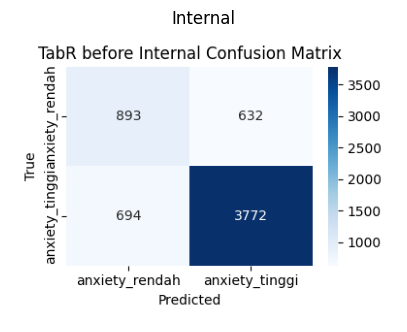

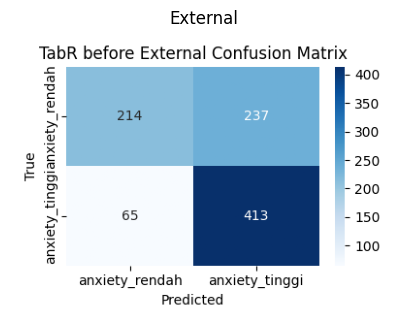


=== INTERNAL CLASSIFICATION REPORT ===
              precision    recall  f1-score      support
0              0.562697  0.585574  0.573907  1525.000000
1              0.856494  0.844604  0.850507  4466.000000
accuracy       0.778668  0.778668  0.778668     0.778668
macro avg      0.709596  0.715089  0.712207  5991.000000
weighted avg   0.781708  0.778668  0.780099  5991.000000

=== EXTERNAL CLASSIFICATION REPORT ===
              precision    recall  f1-score     support
0              0.767025  0.474501  0.586301  451.000000
1              0.635385  0.864017  0.732270  478.000000
accuracy       0.674919  0.674919  0.674919    0.674919
macro avg      0.701205  0.669259  0.659285  929.000000
weighted avg   0.699292  0.674919  0.661407  929.000000
=== AFTER ===


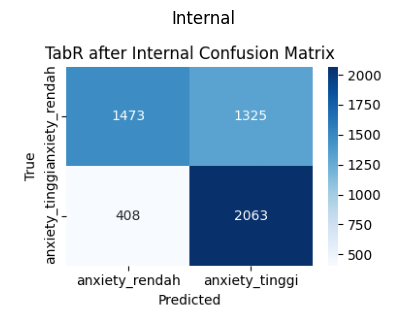

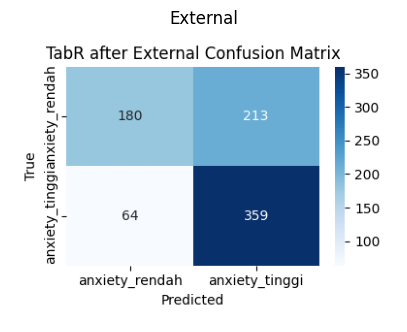


=== INTERNAL CLASSIFICATION REPORT ===
              precision    recall  f1-score      support
0              0.783094  0.526447  0.629622  2798.000000
1              0.608914  0.834885  0.704216  2471.000000
accuracy       0.671095  0.671095  0.671095     0.671095
macro avg      0.696004  0.680666  0.666919  5269.000000
weighted avg   0.701409  0.671095  0.664604  5269.000000

=== EXTERNAL CLASSIFICATION REPORT ===
              precision    recall  f1-score     support
0              0.737705  0.458015  0.565149  393.000000
1              0.627622  0.848700  0.721608  423.000000
accuracy       0.660539  0.660539  0.660539    0.660539
macro avg      0.682664  0.653358  0.643379  816.000000
weighted avg   0.680640  0.660539  0.646255  816.000000


In [10]:
for phase in PHASES:
    print(f'=== {phase.upper()} ===')
    visualize_results(phase_dirs[phase])


before /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t30/before/tabr_logs/version_0/metrics.csv


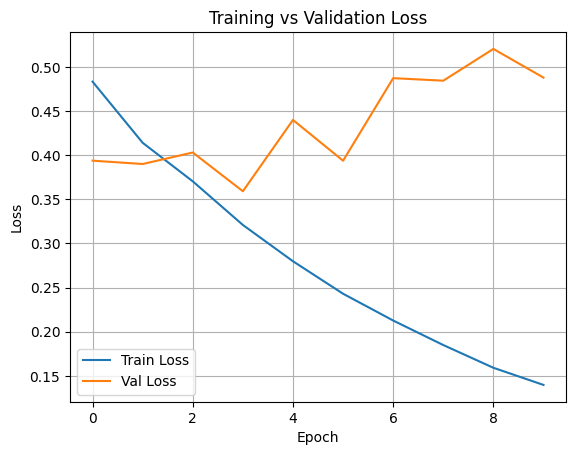

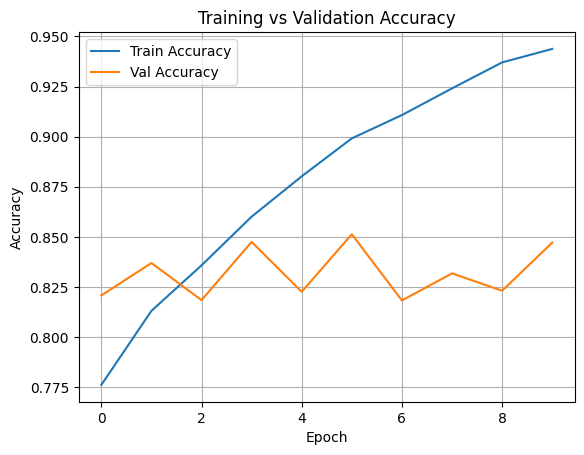

after /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t30/after/tabr_logs/version_0/metrics.csv


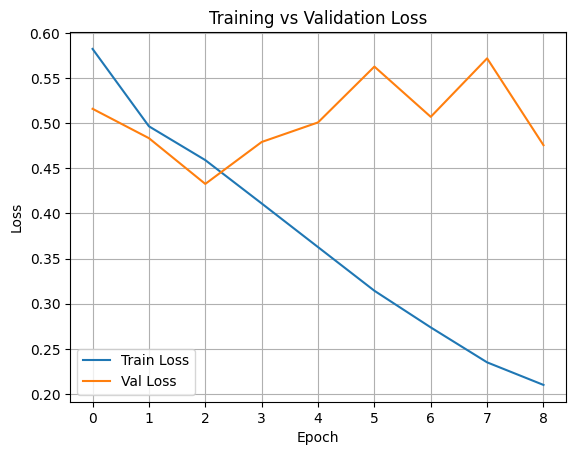

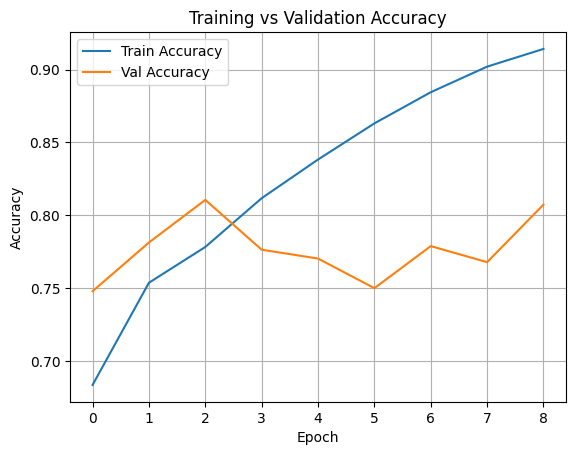

In [11]:
for phase in PHASES:
    metrics_csv = sorted((phase_dirs[phase] / 'tabr_logs').glob('version_*/metrics.csv'))[-1]
    print(phase, metrics_csv)
    plot_lightning_metrics(metrics_csv)


In [12]:
for phase in PHASES:
    print(f'=== {phase.upper()} INTERNAL CM ===')
    print(phase_results[phase]['internal']['cm'])
    print(f'=== {phase.upper()} EXTERNAL CM ===')
    print(phase_results[phase]['external']['cm'])


=== BEFORE INTERNAL CM ===
[[ 893  632]
 [ 694 3772]]
=== BEFORE EXTERNAL CM ===
[[214 237]
 [ 65 413]]
=== AFTER INTERNAL CM ===
[[1473 1325]
 [ 408 2063]]
=== AFTER EXTERNAL CM ===
[[180 213]
 [ 64 359]]


In [13]:
for phase in PHASES:
    print(f'=== EXTERNAL EVENT TABLE [{phase}] ===')
    display(phase_splits[phase]['event_table'][phase_splits[phase]['event_table']['event_id'].isin(phase_splits[phase]['external_event_ids'])].sort_values(['label', 'participant', 'question', 'clip', 'event_clip'], kind='stable').head(50))


=== EXTERNAL EVENT TABLE [before] ===


,event_id,label,target,phase,participant,question,clip,event_clip
224,before||aryan_saputra_rahmad||q1||answer_1_15d...,anxiety_rendah,0,before,aryan_saputra_rahmad,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00080-00092
225,before||aryan_saputra_rahmad||q1||answer_1_15d...,anxiety_rendah,0,before,aryan_saputra_rahmad,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00224-00253
249,before||ashrul_rifki_ardiyhasa||q1||answer_1_1...,anxiety_rendah,0,before,ashrul_rifki_ardiyhasa,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00074-00088
250,before||ashrul_rifki_ardiyhasa||q1||answer_1_1...,anxiety_rendah,0,before,ashrul_rifki_ardiyhasa,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00130-00145
348,before||dewita_anggraini||q1||answer_1_15d591c...,anxiety_rendah,0,before,dewita_anggraini,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00079
349,before||dewita_anggraini||q1||answer_1_15d591c...,anxiety_rendah,0,before,dewita_anggraini,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00126-00166
546,before||fandy_wahyu_hanzura||q1||answer_1_15d5...,anxiety_rendah,0,before,fandy_wahyu_hanzura,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00002-00055
547,before||fandy_wahyu_hanzura||q1||answer_1_15d5...,anxiety_rendah,0,before,fandy_wahyu_hanzura,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00072-00100
571,before||fiera_ziadattun_nisa_||q1||answer_1_15...,anxiety_rendah,0,before,fiera_ziadattun_nisa_,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00005-00017
572,before||fiera_ziadattun_nisa_||q1||answer_1_15...,anxiety_rendah,0,before,fiera_ziadattun_nisa_,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00079


=== EXTERNAL EVENT TABLE [after] ===


,event_id,label,target,phase,participant,question,clip,event_clip
49,after||abdul_aziz||q1||answer_1_15d591ce-051a-...,anxiety_rendah,0,after,abdul_aziz,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00006-00024
74,after||achmad_anfasa_rabbany||q1||answer_1_15d...,anxiety_rendah,0,after,achmad_anfasa_rabbany,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00044-00076
123,after||ahmad_rifqi_hendriansyah||q1||answer_1_...,anxiety_rendah,0,after,ahmad_rifqi_hendriansyah,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00089-00094
148,after||aida_rahma_fadhila||q1||answer_1_15d591...,anxiety_rendah,0,after,aida_rahma_fadhila,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00119-00135
173,after||akhmad_aakhif_athallah||q1||answer_1_15...,anxiety_rendah,0,after,akhmad_aakhif_athallah,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00217-00239
223,after||aryan_saputra_rahmad||q1||answer_1_15d5...,anxiety_rendah,0,after,aryan_saputra_rahmad,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00007-00018
248,after||ashrul_rifki_ardiyhasa||q1||answer_1_15...,anxiety_rendah,0,after,ashrul_rifki_ardiyhasa,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00001-00021
273,after||ayleen_ruhul_qisthy||q1||answer_1_15d59...,anxiety_rendah,0,after,ayleen_ruhul_qisthy,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00159-00195
297,after||billy_maulana_ferdinan||q1||answer_1_15...,anxiety_rendah,0,after,billy_maulana_ferdinan,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00014-00026
421,after||ericha_rizki_wardani||q1||answer_1_15d5...,anxiety_rendah,0,after,ericha_rizki_wardani,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00006-00013


In [14]:
for phase in PHASES:
    split_data = phase_splits[phase]
    print(f'=== DISTRIBUTION [{phase.upper()}] ===')
    print('train rows by label')
    print(split_data['df_tr']['label'].value_counts(dropna=False).sort_index())
    print()
    print('val rows by label')
    print(split_data['df_val']['label'].value_counts(dropna=False).sort_index())
    print()
    print('external rows by label')
    print(split_data['df_external']['label'].value_counts(dropna=False).sort_index())
    print()
    print('train events by label')
    print(split_data['df_tr'][['event_id', 'label']].drop_duplicates()['label'].value_counts(dropna=False).sort_index())
    print()
    print('val events by label')
    print(split_data['df_val'][['event_id', 'label']].drop_duplicates()['label'].value_counts(dropna=False).sort_index())
    print()
    print('external events by label')
    print(split_data['df_external'][['event_id', 'label']].drop_duplicates()['label'].value_counts(dropna=False).sort_index())
    print()
    print('participant distribution by label')
    print('train')
    print(split_data['df_tr'].groupby('label')['participant'].nunique())
    print('val')
    print(split_data['df_val'].groupby('label')['participant'].nunique())
    print('external')
    print(split_data['df_external'].groupby('label')['participant'].nunique())
    print()


=== DISTRIBUTION [BEFORE] ===
train rows by label
label
anxiety_rendah     5698
anxiety_tinggi    18375
Name: count, dtype: int64

val rows by label
label
anxiety_rendah    1525
anxiety_tinggi    4466
Name: count, dtype: int64

external rows by label
label
anxiety_rendah    451
anxiety_tinggi    478
Name: count, dtype: int64

train events by label
label
anxiety_rendah    279
anxiety_tinggi    799
Name: count, dtype: int64

val events by label
label
anxiety_rendah     70
anxiety_tinggi    200
Name: count, dtype: int64

external events by label
label
anxiety_rendah    20
anxiety_tinggi    20
Name: count, dtype: int64

participant distribution by label
train
label
anxiety_rendah    15
anxiety_tinggi    41
Name: participant, dtype: int64
val
label
anxiety_rendah    15
anxiety_tinggi    41
Name: participant, dtype: int64
external
label
anxiety_rendah    15
anxiety_tinggi    20
Name: participant, dtype: int64

=== DISTRIBUTION [AFTER] ===
train rows by label
label
anxiety_rendah    10811
anx

In [15]:
comparison_df


,phase,split,accuracy
0,before,internal,0.778668
1,before,external,0.674919
2,after,internal,0.671095
3,after,external,0.660539
